### Balanço Viés-Variança

In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load the California housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Create and train the Ridge Regression model
model = Ridge(alpha=1.0, solver='auto', random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
score = model.score(X_test, y_test)
print(f"Model score: {score}")

Model score: 0.5957897259773939


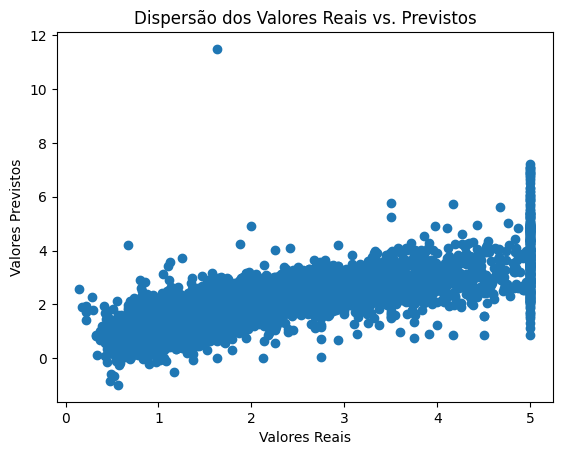

In [4]:
# Agora vamos plotar o gráfico de dispersão dos valores reais versus os valores previstos
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.title("Dispersão dos Valores Reais vs. Previstos")
plt.show()

### Ridge Regression

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

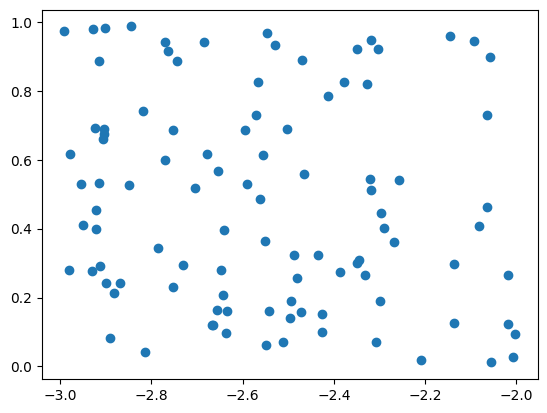

In [14]:
m = 100
x = np.random.rand(m, 1)-3
y = np.random.rand(m, 1)
plt.scatter(x, y)

c:\Users\danillo.araujo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6786613240037684e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


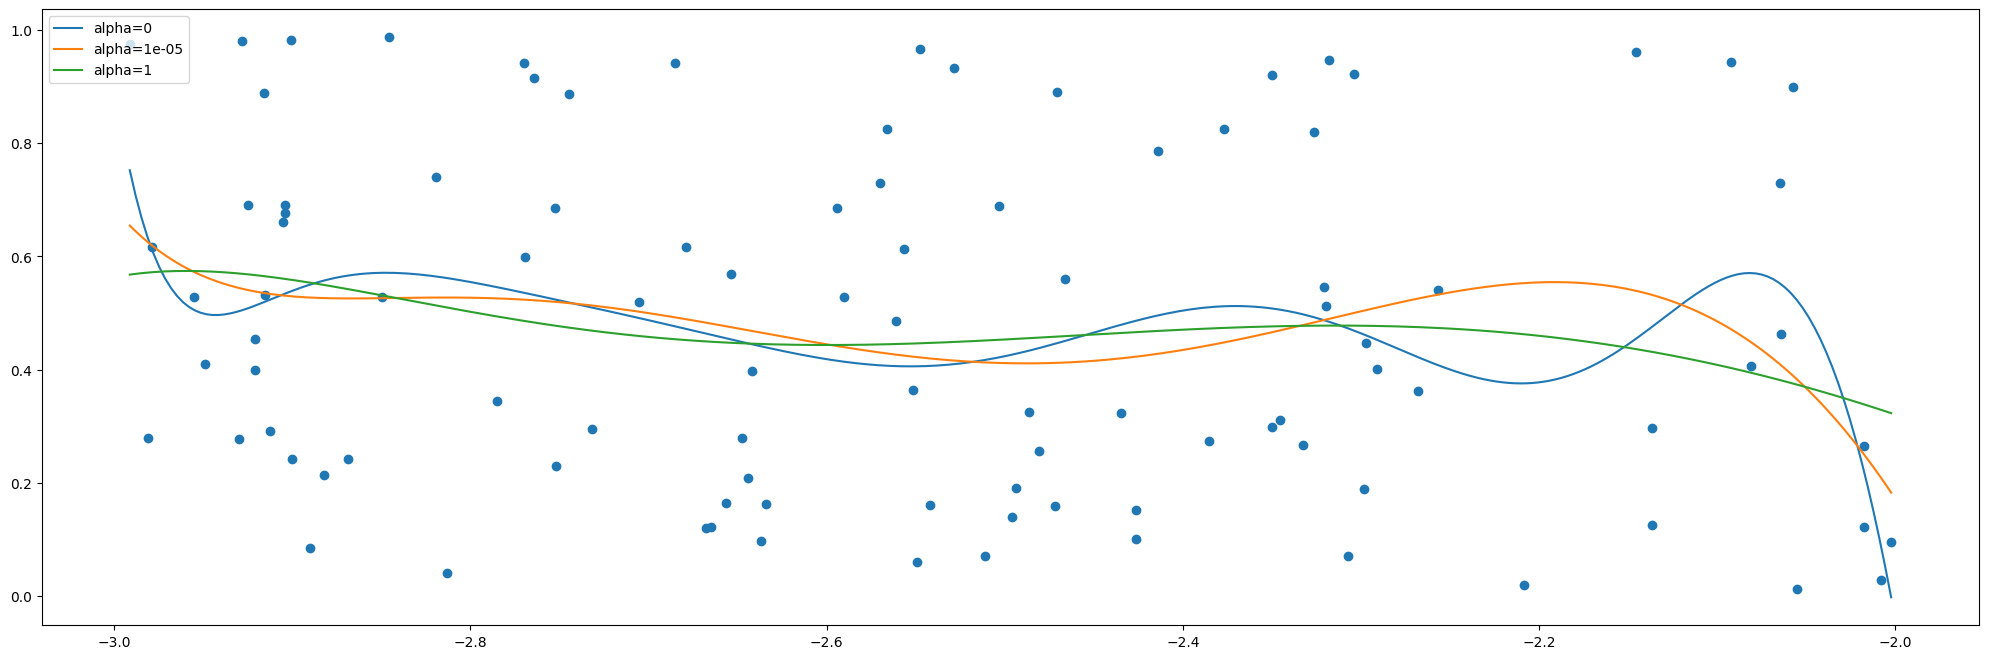

In [21]:
fig, ax = plt.subplots(figsize=(25,8))
plt.scatter(x, y)

for alpha in [0, 1e-5, 1]:
    poly_features = PolynomialFeatures(degree=10, include_bias=False)
    x_poly = poly_features.fit_transform(x)
    x_seq = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)

    ridge_reg = Ridge(alpha=alpha, solver='cholesky', random_state=42)
    ridge_reg.fit(x_poly, y)
    x_seq_transformed = poly_features.fit_transform(x_seq)
    plt.plot(x_seq, ridge_reg.predict(x_seq_transformed), label=f"alpha={alpha}")
    
ax.legend(loc="upper left")